# **Set up**

In [5]:
%run ../../../setup_workspace.py # ../ means level up 
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.ticker as ticker

# **Data**

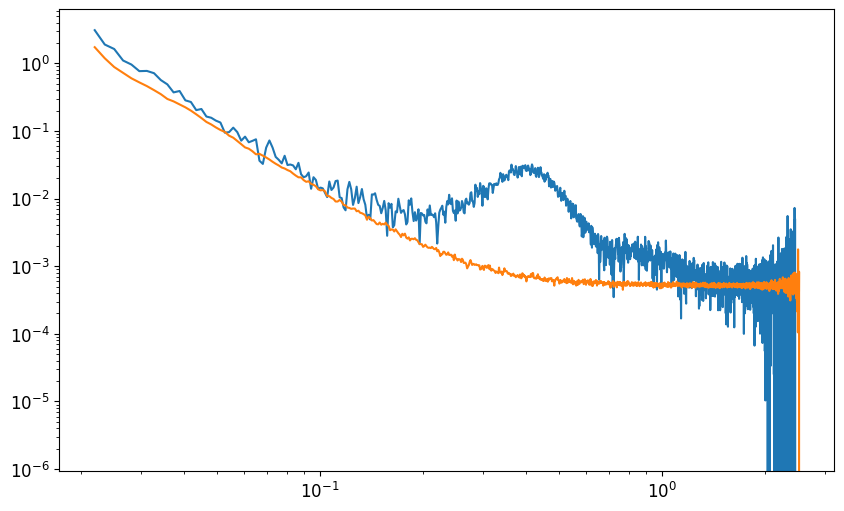

In [6]:

path = r"\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00293_00_ave.h5"

Exp_Heat = ID02_experiment(path)
q, I = Exp_Heat.get_1d_data(60)
plt.loglog(q, I)

path = r'\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00034_00_ave.h5'
q, bkg1 = ID02_experiment(path).get_1d_data()

path = r'\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00038_00_ave.h5'
q, bkg2 =  ID02_experiment(path).get_1d_data()

path = r'\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00037_00_ave.h5'
q, bkg3 =  ID02_experiment(path).get_1d_data()

bkg =( bkg1 + bkg2 + bkg3) / 3
plt.loglog(q, bkg)
# plt.loglog(q, I - bkg)


# **Functions**

In [7]:
def average(Exp, index):
    q, res = Exp.get_1d_data()
    res *= 0
    
    for i in index:
        q, I = Exp.get_1d_data(i)
        res += I
    res /= len(index)
    return q, res

In [20]:
def power(x, k, b):
    return k * x ** b

def linear(x, k, b):
    return k * x + b

def gauss(x, A, x0, sigma, bg):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + bg

def lognorm(x, A, x0, sigma, bg):
    return A * np.exp(-(np.log(x) - np.log(x0))**2 / (2 * sigma**2)) + bg
    
def power_gauss(x, A, x0, sigma, bg, k, b):
    return power(x, k, b) + gauss(x, A, x0, sigma, bg)

def power_lognorm(x, A, x0, sigma, bg, k, b):
    return power(x, k, b) + lognorm(x, A, x0, sigma, bg)

def porod(q, A):
    return A * q ** -4

def Lorenz(x, y, p = 2):
    return x, y * x ** p

def IDF(z, K):
    d1 = np.gradient(K, z)
    return np.gradient(d1, z)

In [9]:
def K(q, I, z):
    return np.trapezoid(I[:, None] * np.cos(q[:, None] * z[None, :]), q, axis=0)

In [27]:
def analyze_saxs(q, I, qmin=0.0, porod_start=0.8, left_lin=0, right_lin=1, plot=True):
    """
    SAXS analysis with Porod fitting and correlation function.
    
    Parameters:
    -----------
    q : array
        Scattering vector (nm^-1)
    I : array
        Intensity (a.u.) - already background subtracted
    qmin : float
        Minimum q for data truncation
    porod_start : float
        Starting q for Porod fit
    left_lin, right_lin : float
        Range for linear fit of correlation function
    plot : bool
        If True, create plots
    
    Returns:
    --------
    dict : {
        'Corr': correlation function,
        'Lp': long period (nm),
        'Lc': crystalline thickness (nm),
        'La': amorphous thickness (nm),
        'z': z-axis (nm),
        'q_new': combined q,
        'I_new': combined I
    }
    """
    
    # Remove negative intensities
    mask = I > 0
    q_clean = q[mask]
    I_clean = I[mask]
    
    # Fit Porod
    mask_fit = (q_clean > porod_start * 0.8) & (q_clean < 1.8)
    X_fit = q_clean[mask_fit]
    Y_fit = I_clean[mask_fit]
    
    p, _ = curve_fit(porod, X_fit, Y_fit)
    
    # Generate Porod tail
    X_porod = np.linspace(porod_start, 20, 3000)
    Y_porod = porod(X_porod, p)
    
    # Combine data
    mask_main = (q_clean < porod_start) & (q_clean > qmin)
    q_new = np.concatenate([q_clean[mask_main], X_porod])
    I_new = np.concatenate([I_clean[mask_main], Y_porod])
    
    # Lorenz correction (I * q^2)
    I_lorenz = I_new * q_new ** 2
    
    # Correlation function
    dz = 2 * np.pi / max(q_new)
    z = np.linspace(dz, 50, int(50 / dz))
    Corr = K(q_new, I_lorenz, z)
    Corr /= max(Corr)
    idf = IDF(z, Corr)
    idf /= 2 * max(idf[z<20])
    # Find peaks (Lp) and minima (La)
    peaks, _ = find_peaks(Corr, distance=5)
    mins, _ = find_peaks(-Corr, distance=5)
    
    if len(peaks) == 0 or len(mins) == 0:
        print("Warning: No peaks or minima found")
        return None
    
    Lp = z[peaks[0]]
    K_min = Corr[mins[0]]
    
    # Linear fit for La
    mask_lin = (z > left_lin) & (z < right_lin)
    p_lin, _ = curve_fit(linear, z[mask_lin], Corr[mask_lin])
    La = (K_min - p_lin[1]) / p_lin[0]
    Lc = Lp - La
    
    # Plotting
    if plot:
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        
        # Plot 1: Data + Porod
        ax[0].loglog(q_clean, I_clean, label='Data')
        ax[0].loglog(X_porod, Y_porod, 'r--', label='Porod fit')
        ax[0].loglog(q_new, I_new * 0.1, 'k-', alpha=0.5, label='Combined')
        ax[0].set_xlabel('q (nm⁻¹)')
        ax[0].set_ylabel('I (a.u.)')
        ax[0].legend()
        
        # Plot 2: Lorenz-corrected
        ax[1].plot(q_new, I_new * q_new ** 2, 'k-')
        ax[1].set_xlim(0, 2)
        ax[1].set_xlabel('q (nm⁻¹)')
        ax[1].set_ylabel('I · q² (a.u.)')
        
        # Plot 3: Correlation function
        ax[2].plot(z, Corr, 'k-', label='K(z)')
        ax[2].plot(z, idf, color='r', label='idf(z)')
        ax[2].axhline(0, color='grey', linestyle='--')
        ax[2].scatter(z[peaks], Corr[peaks], color='r', s=20, label='Peaks')
        ax[2].scatter(z[mins], Corr[mins], color='b', s=20, label='Minima')
        ax[2].axhline(K_min, color='b', alpha=0.2)
        ax[2].plot(z, linear(z, *p_lin), 'b--', label='Linear fit')
        
        # Mark Lp, Lc, La
        ax[2].scatter(Lp, K_min, marker='*', s=200, color='r', label=f'Lp = {Lp:.2f} nm')
        ax[2].scatter(Lc, K_min, marker='*', s=200, color='g', label=f'Lc = {Lc:.2f} nm')
        ax[2].scatter(La, K_min, marker='*', s=200, color='b', label=f'La = {La:.2f} nm')
        
        ax[2].set_xlim(0, 20)
        ax[2].set_ylim(min(Corr) * 1.1, 1.1)
        ax[2].set_xlabel('z (nm)')
        ax[2].set_ylabel('K(z)')
        # ax[2].legend()
        
        plt.tight_layout()
        plt.show()
    
    return {
        'Corr': Corr,
        'Lp': Lp,
        'Lc': Lc,
        'La': La,
        'z': z,
        'q_new': q_new,
        'I_new': I_new,
        'peaks': peaks,
        'mins': mins,
        'linear_fit': p_lin
    }

# **Analysis**

### Heating exp

In [11]:
def average(Exp, index):
    q, res = Exp.get_1d_data()
    res *= 0
    
    for i in index:
        q, I = Exp.get_1d_data(i)
        res += I
    res /= len(index)
    return q, res

def porod(x, A):
    return A * x ** -4

def linear(x, k, b):
    return k * x + b

def T_programm(x):
    """Векторизованная кусочно-линейная функция температуры"""
    xp = np.array([0, 50, 175, 185, 310, 360])
    fp = np.array([0, 0, 125, 125, 0, 0])
    return np.interp(x, xp, fp, left=0, right=0)

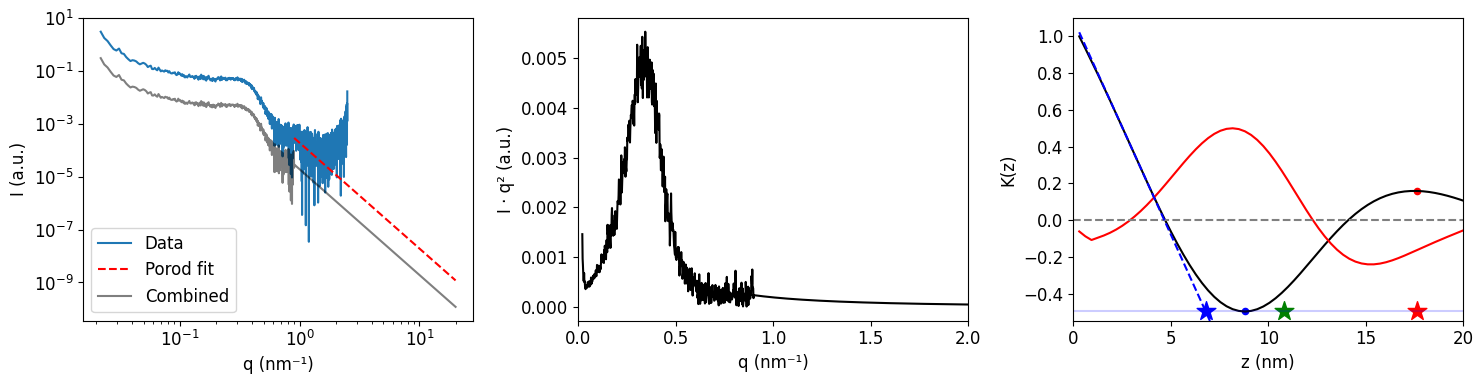

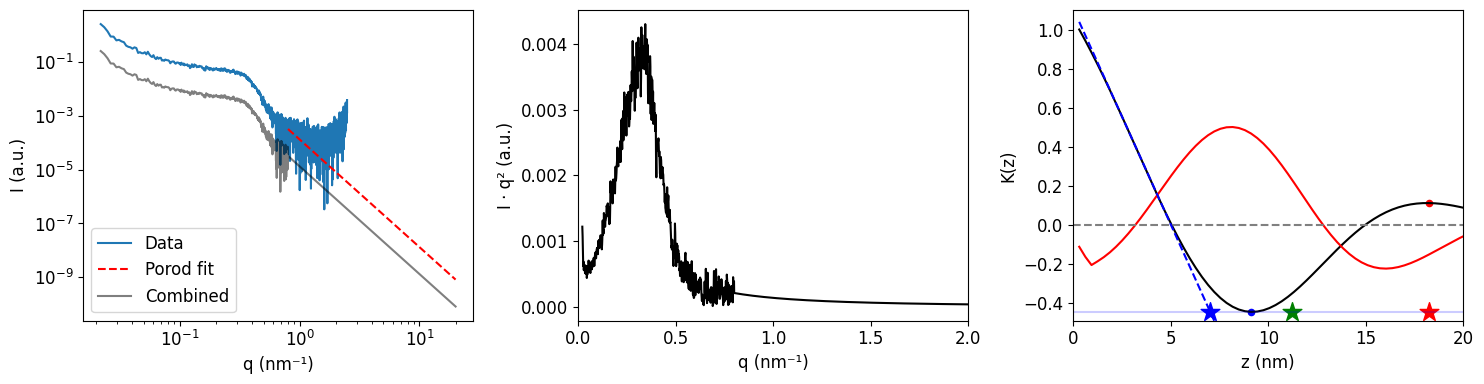

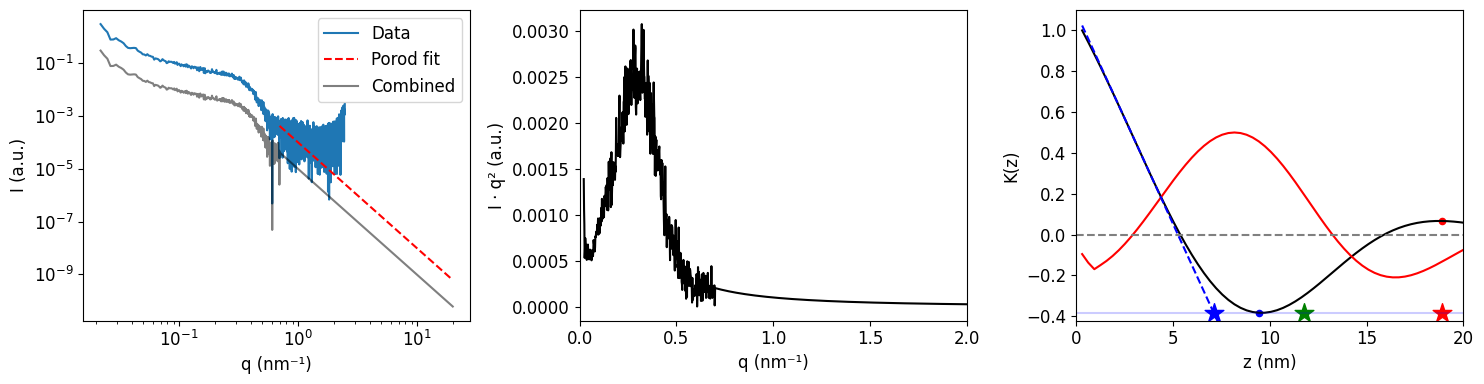

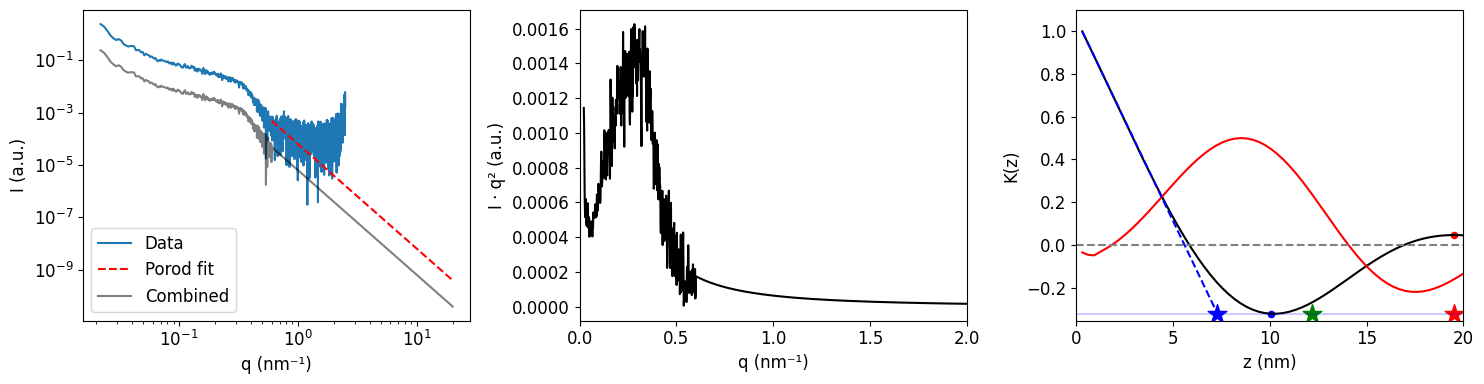

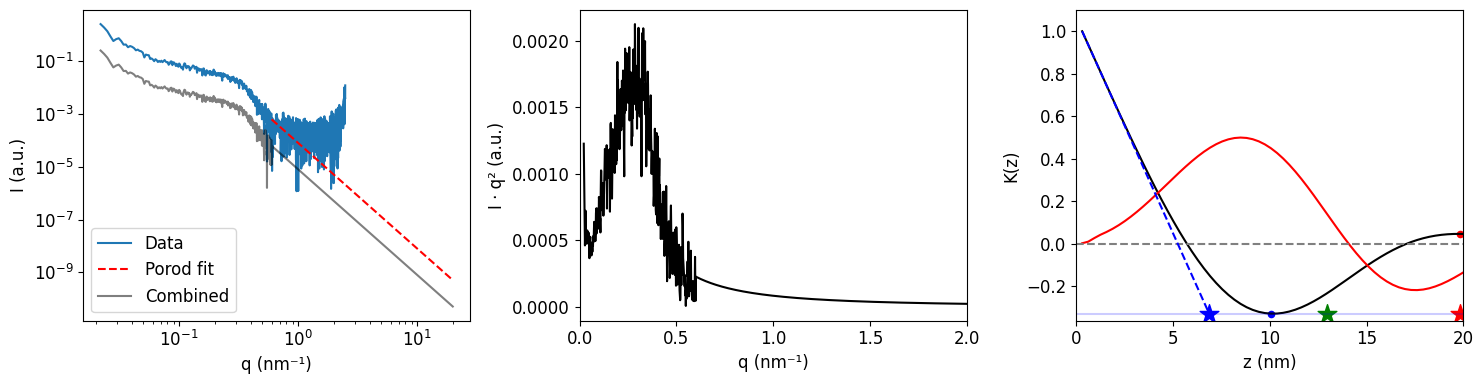

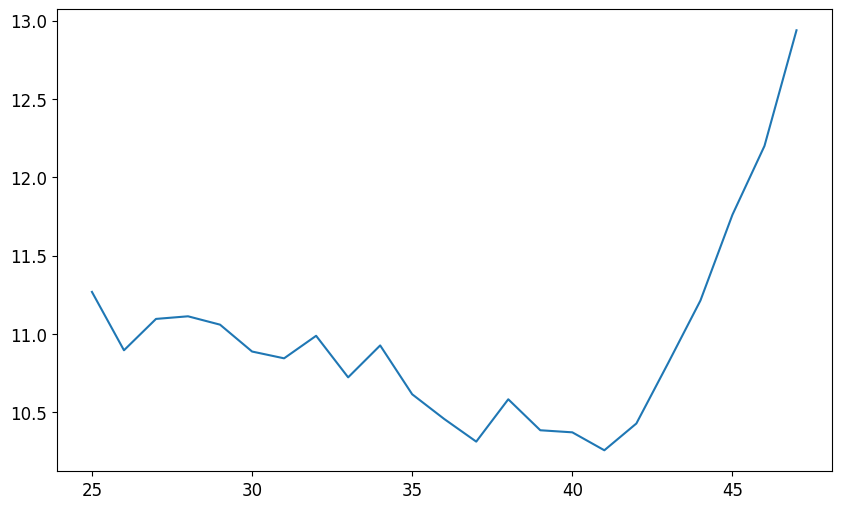

In [28]:

Lc = []
Lp = []
indices = []
for i in range(25, 48):
    if i < 43:
        q, I = average(Exp_Heat, [2 * i, 2 * i + 1])
        I -=  bkg
        if i == 37:
            res = analyze_saxs(q, I, qmin=0.02, porod_start=1., left_lin=0, right_lin=1, plot=False)
        else:
            res = analyze_saxs(q, I, qmin=0.02, porod_start=1., left_lin=0, right_lin=1, plot=False)
            
        Lc.append(res['Lc'])
        Lp.append(res['Lp'])
    else:
        if i == 43:
            q, I = average(Exp_Heat, [2 * i, 2 * i + 1])
            I -=  bkg
            res = analyze_saxs(q, I, qmin=0.02, porod_start=.9, left_lin=2, right_lin=3, plot=True)
            Lc.append(res['Lc'])
            Lp.append(res['Lp'])

        if i == 44:
            q, I = average(Exp_Heat, [2 * i, 2 * i + 1])
            I -=  bkg
            res = analyze_saxs(q, I, qmin=0.02, porod_start=.8, left_lin=2, right_lin=3, plot=True)
            Lc.append(res['Lc'])
            Lp.append(res['Lp'])

        if i == 45:
            q, I = average(Exp_Heat, [2 * i, 2 * i + 1])
            I -=  bkg
            res = analyze_saxs(q, I, qmin=0.02, porod_start=.7, left_lin=2, right_lin=3, plot=True)
            Lc.append(res['Lc'])
            Lp.append(res['Lp'])
        if i == 46:
            q, I = average(Exp_Heat, [2 * i, 2 * i + 1])
            I -=  bkg
            res = analyze_saxs(q, I, qmin=0.02, porod_start=.6, left_lin=0, right_lin=1, plot=True)
            Lc.append(res['Lc'])
            Lp.append(res['Lp'])
        if i == 47:
            q, I = average(Exp_Heat, [2 * 46])
            I -=  bkg
            res = analyze_saxs(q, I, qmin=0.02, porod_start=.6, left_lin=0, right_lin=1, plot=True)
            Lc.append(res['Lc'])
            Lp.append(res['Lp'])
plt.plot(range(25, 48), Lc)

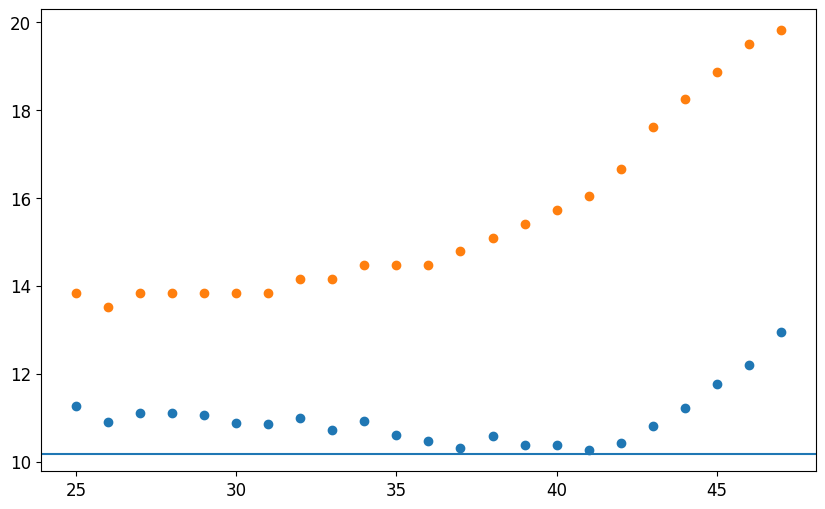

In [16]:
plt.scatter(range(25, 48), Lc)
plt.scatter(range(25, 48), Lp)
plt.axhline(y=10.18)

### NC 

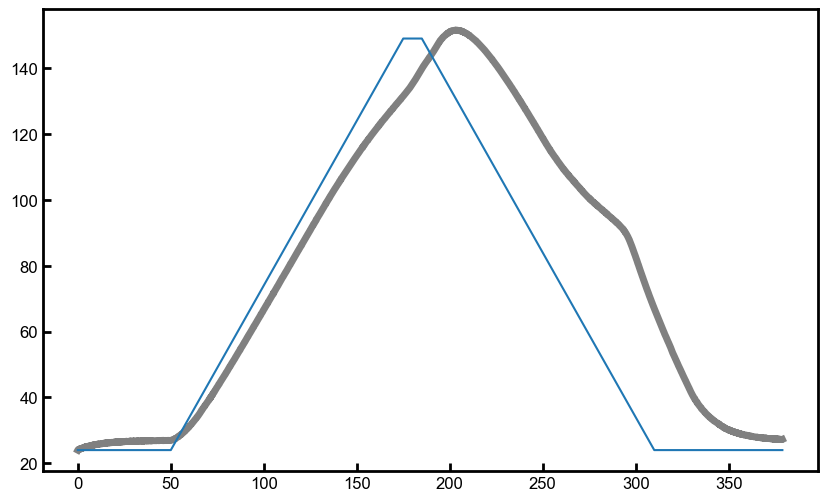

In [56]:
path = r"\\Synology\Data\2025\ESRF_SC5671\NANOCAL\DATA\2025-06-20-sc5671_ID02\C390_3m_20deg_min_cooling_S2_run2_293.txt"
# path = r"\\Synology\Data\2025\ESRF_SC5671\NANOCAL\DATA\2025-06-20-sc5671_ID02\test.txt"

NC = pd.read_csv(path, skiprows=2, sep='	', names=['t', 'T', 1,2,3,4,5,6,7])

time = NC['t']
T = NC['T']
plt.plot(time, T, label='exp', linewidth=5, zorder=0, color='grey')
plt.plot(time, T_programm(time)+24, label='Programm')


In [57]:
from scipy.interpolate import Akima1DInterpolator
def get_background(x, y, l, r):
    mask = np.ones(len(x), dtype=bool)
    mask[l:r+1] = False
    interp = Akima1DInterpolator(x[mask], y[mask])
    return interp(x)

from scipy.interpolate import UnivariateSpline

def get_background_spline(x, y, l, r, s=0):
    mask = np.ones(len(x), dtype=bool)
    mask[l:r+1] = False
    spline = UnivariateSpline(x[mask], y[mask], s=s, ext='extrapolate')
    return spline(x)

from scipy.interpolate import PchipInterpolator

def get_background_pchip(x, y, l, r):
    mask = np.ones(len(x), dtype=bool)
    mask[l:r+1] = False
    interp = PchipInterpolator(x[mask], y[mask], extrapolate=True)
    return interp(x)

def get_background_poly(x, y, l, r, deg=3):
    mask = np.ones(len(x), dtype=bool)
    mask[l:r+1] = False
    coeffs = np.polyfit(x[mask], y[mask], deg)
    return np.polyval(coeffs, x)

C:\Users\LabPCA\AppData\Local\Temp\ipykernel_7444\2332143313.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  p, cov = curve_fit(linear, [time[l], time[r]], [T[l], T[r]])


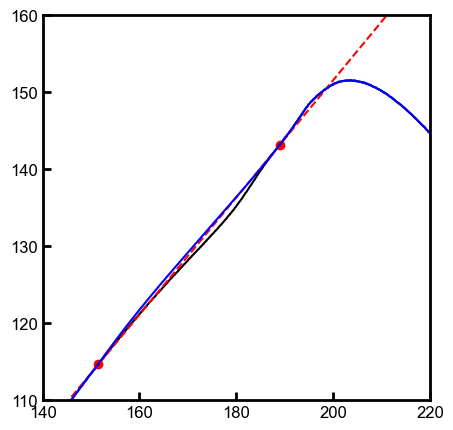

In [58]:
plt.figure(figsize=(5,5))
plt.xlim(140, 220)
plt.ylim(110, 160)
l, r = 1515, 1890
plt.plot(time, T, color='black')
plt.scatter([time[l], time[r]], [T[l], T[r]], color='r')

p, cov = curve_fit(linear, [time[l], time[r]], [T[l], T[r]])
plt.plot(time, linear(time, *p), color='r', linestyle='--')

func = get_background_pchip
plt.plot(time, func(time, T, l, r), color='blue')

new_res = func(time, T, l, r)-T

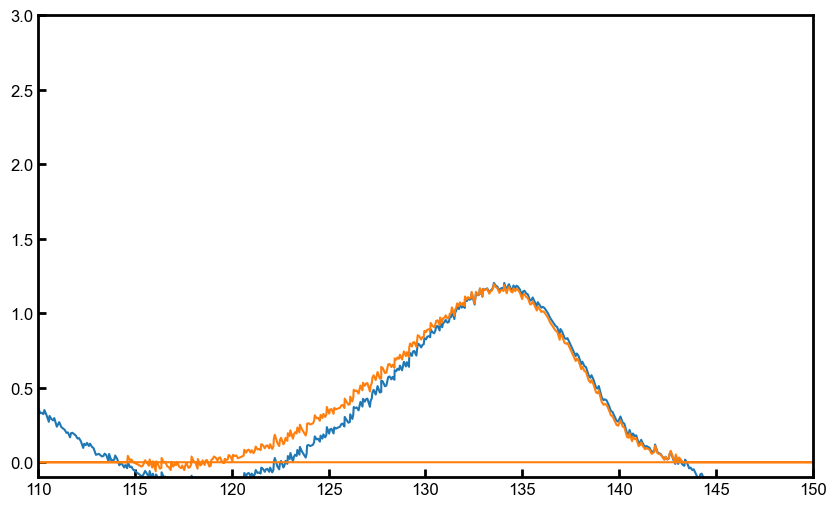

In [59]:
plt.xlim(110, 150)
plt.ylim(-0.1, 3 )
plt.plot(T, linear(time, *p)-T)
plt.plot(T, get_background(time, T, l, r)-T)

NC_T = T[(T>115)*(T<148)]
NC_deltaT = (linear(time, *p)-T)[(T>115)*(T<148)]

In [60]:
indices = np.arange(25, 48)
# Ваш массив Time_exp
Time_exp = indices * 2 * 1.9

# Для каждого значения Time_exp ищем ближайшее в time и берем T
T_exp = []
for t_target in Time_exp:
    pos = np.argmin(np.abs(time - t_target))
    T_exp.append(T[pos])

T_exp = np.array(T_exp)

# Проверка
for i in range(5):
    print(f"Time_exp[{i}] = {Time_exp[i]:.2f} -> T_exp = {T_exp[i]:.2f}°C")

Time_exp[0] = 95.00 -> T_exp = 61.89°C
Time_exp[1] = 98.80 -> T_exp = 65.51°C
Time_exp[2] = 102.60 -> T_exp = 69.16°C
Time_exp[3] = 106.40 -> T_exp = 72.80°C
Time_exp[4] = 110.20 -> T_exp = 76.50°C


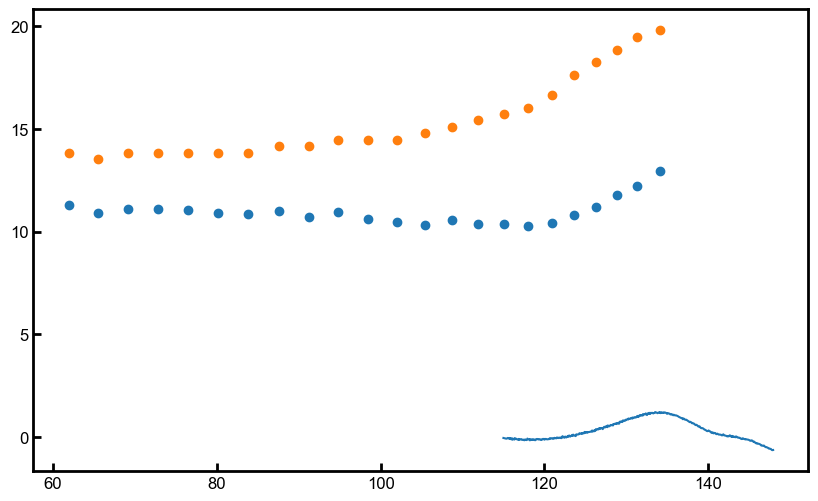

In [61]:
plt.scatter(T_exp, Lc)
plt.scatter(T_exp, Lp)
plt.plot(NC_T[NC_deltaT<10], NC_deltaT[NC_deltaT<10])


In [62]:
0.75 / 2 + 0.15

0.525

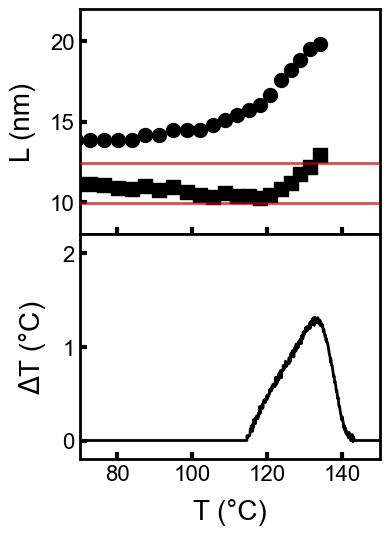

In [63]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 6), sharex=True)
fig.subplots_adjust(left=0.15, right=0.9, bottom=0.12, top=0.92, hspace=0)
ax1.set_position([0.15, 0.525, 0.75, 0.375])
ax2.set_position([0.15, 0.15, 0.75, 0.375])
# Верхний график: Lc и Lp
ax1.scatter(T_exp, Lc, color='black', s=100, label='L$_c$', marker='s')
ax1.scatter(T_exp, Lp, color='black', s=100, label='L$_p$', marker='o')
ax1.axhline(y=49.7/5, color='#bf0603', linewidth=2, zorder=10, alpha=0.7)
ax1.axhline(y=49.7/4, color='#bf0603', linewidth=2, zorder=10, alpha=0.7)
# ax1.axhline(y=49.7/3, color='#bf0603', linewidth=2, zorder=10, alpha=0.7)

ax1.set_ylim(8, 22)
ax1.set_xlim(70, 150)
ax2.set_ylim(-0.1, 2.1)
ax1.set_ylabel('L (nm)', fontname='Arial', fontsize=20, labelpad=10)

# Нижний график: дельта T
ax2.plot(T[:2100], new_res[:2100], color='black', linewidth=2)
ax2.set_ylabel('$\\Delta$T (°C)', fontname='Arial', fontsize=20, labelpad=10)
ax2.set_xlabel('T (°C)', fontname='Arial', fontsize=20, labelpad=10)
ax2.set_yticks([0, 1, 2])
ax2.set_ylim([-0.2, 2.2])
# Настройка тиков для обоих графиков
for ax in [ax1, ax2]:
    ax.tick_params(axis='both', which='major', direction='in', width=3, length=5, labelsize=16)
    ax.tick_params(axis='both', which='minor', direction='in', width=2, length=3)

plt.savefig(r'C:\Users\LabPCA\Desktop\Fig_heat_Lc.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

# **Figures**

In [32]:
path = r"\\Synology\Data\2025\ESRF_SC5671\ef20\ef20_20250620-091305\ef20_eiger2_00293_00_ave.h5"

Exp = ID02_experiment(path)

def average(Exp, index):
    q, res = Exp.get_1d_data()
    res *= 0
    
    for i in index:
        q, I = Exp.get_1d_data(i)
        res += I
    res /= len(index)
    return q, res
from scipy.signal import savgol_filter


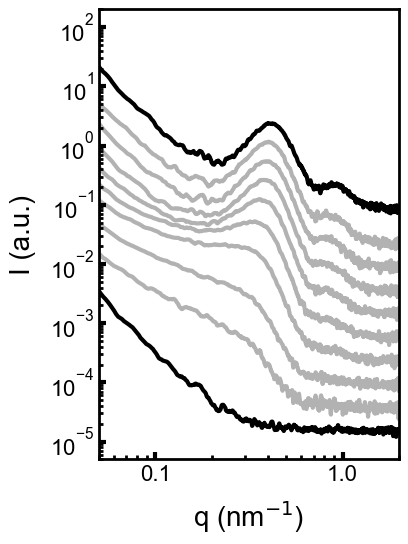

In [34]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

scale = 2.5
linewidth = 3
window = 15
# color_array = ["#009bff","#49b7ff","#78c9ff","#a9dcff","#e7f2fa","#eabbc1","#e99398","#e86c6f","#e73a3c","#973738"]
color_array = ["black","black","black","black","black","black","black","black","black","black"]

alpha = 0.3

indexes = [i for i in range(0, 10)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 5 * 1.5, color=color_array[0], linewidth=linewidth)

indexes = [i for i in range(60, 65)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 4, color=color_array[1], linewidth=linewidth, alpha=alpha)

indexes = [i for i in range(65, 70)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 3, color=color_array[2], linewidth=linewidth, alpha=alpha)

indexes = [i for i in range(70, 75)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 2, color=color_array[3], linewidth=linewidth, alpha=alpha)

indexes = [i for i in range(75, 80)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 1, color=color_array[4], linewidth=linewidth, alpha=alpha)

indexes = [i for i in range(80, 85)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** 0, color=color_array[5], linewidth=linewidth, alpha=alpha)

indexes = [i for i in range(85, 90)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** -1, color=color_array[6], linewidth=linewidth, alpha=alpha)

indexes = [i for i in range(90, 95)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** -2, color=color_array[7], linewidth=linewidth, alpha=alpha)

indexes = [i for i in range(93, 96)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** -3, color=color_array[8], linewidth=linewidth, alpha=alpha)

indexes = [i for i in range(100, 110)]
q, I = average(Exp,indexes)
I_smooth = savgol_filter(I, window_length=window, polyorder=3)
ax.plot(q, I_smooth * scale ** -4, color=color_array[9], linewidth=linewidth)

ax.set_xlim(0.05, 2)
ax.set_ylim(5e-6, 2e2)
ax.set_xscale('log')
ax.set_yscale('log')

ax.xaxis.set_major_locator(ticker.FixedLocator([0.1, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)

ax.tick_params(axis="both", which='major', direction="in", width=3, length=5, labelsize=16)
ax.tick_params(axis="both", which='minor', direction="in", width=2, length=3)


ax.set_position([0.15, 0.15, 0.75, 0.75])
# plt.savefig(r'E:\C390\Figures\Fig2.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

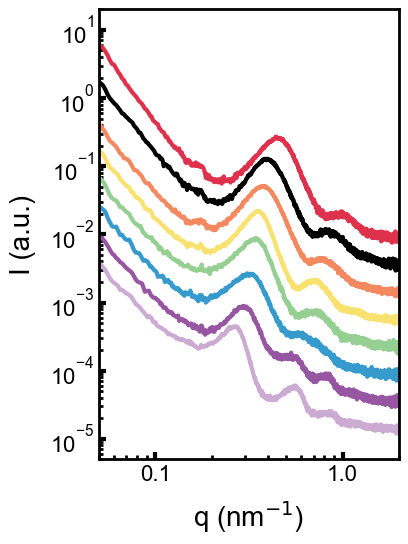

In [39]:
# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

scale = 2.5
linewidth = 3

# Ваши данные
path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00294_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 3, label='after quenching', linewidth=linewidth, color='#de324c')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00290_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 2, label='1000 K/s', linewidth=linewidth, color='black')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00299_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 1, label='100 K/s', linewidth=linewidth, color='#f4895f')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00302_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** 0, label='10 K/s', linewidth=linewidth, color='#f8e16f')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00305_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -1, label='5 K/s', linewidth=linewidth, color='#95cf92')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00301_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -2, label='1 K/s', linewidth=linewidth, color='#369acc')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00291_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -3, label='0.333 K/s', linewidth=linewidth, color='#9656a2')

path = r"E:\C390\SCATTERING-DATA\ef20\ef20_eiger2_00296_00_00001_av.dat"
df = pd.read_csv(path, skiprows=2, names=['q', 'I', 'err'], sep='\t')
q, I = np.array(df['q']), np.array(df['I'])
ax.plot(q, I * scale ** -4, label='0.017 K/s', linewidth=linewidth, color='#cbabd1')

ax.set_xlim(0.05, 2)
ax.set_ylim(5e-6, 2e1)
ax.set_xscale('log')
ax.set_yscale('log')

ax.xaxis.set_major_locator(ticker.FixedLocator([0.1, 1]))
# ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)

ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20, labelpad=10)

ax.tick_params(axis="both", which='major', direction="in", width=3, length=5, labelsize=16)
ax.tick_params(axis="both", which='minor', direction="in", width=2, length=3)

plt.savefig(r'E:\C390\Figures\Fig1_a.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

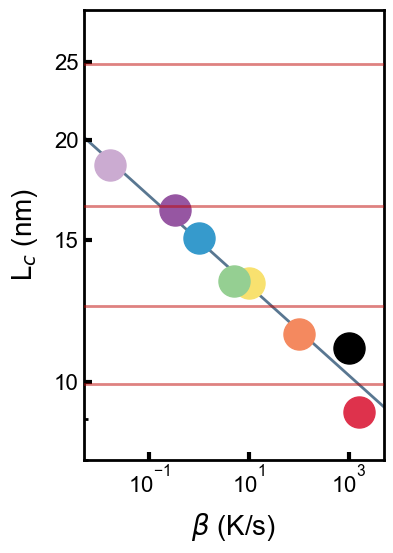

In [66]:
res = pd.read_csv(r'C:\Users\LabPCA\Desktop\res_static.txt', sep='\t')

# ===================== СТИЛЬ ДЛЯ ПУБЛИКАЦИИ =====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
# =================================================================

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
ax.set_position([0.15, 0.15, 0.75, 0.75])

rate = res['cooling_rate']
d_cr = res['d_cr']
Lp = res['Lp']

s_Lc = 500
s_Lp = 400

def power(x, a, b):
    return a * x ** b

# Lc (кружки)
ax.scatter(rate[0], d_cr[0], color='#de324c', s=s_Lc, marker='o', zorder=5)
ax.scatter(rate[1], d_cr[1], color='black', s=s_Lc, marker='o', zorder=5)
ax.scatter(rate[2], d_cr[2], color='#f4895f', s=s_Lc, marker='o', zorder=5)
ax.scatter(rate[3], d_cr[3], color='#f8e16f', s=s_Lc, marker='o', zorder=5)
ax.scatter(rate[4], d_cr[4], color='#95cf92', s=s_Lc, marker='o', zorder=5)
ax.scatter(rate[5], d_cr[5], color='#369acc', s=s_Lc, marker='o', zorder=5)
ax.scatter(rate[6], d_cr[6], color='#9656a2', s=s_Lc, marker='o', zorder=5)
ax.scatter(rate[7], d_cr[7], color='#cbabd1', s=s_Lc, marker='o', zorder=5)

p, _ = curve_fit(power, rate, d_cr)
x = np.linspace(1e-3, 3e4, 1000)
ax.plot(x, power(x, *p), color='#577590', alpha=0.99, zorder=0, linewidth=2)

# # Lp (квадраты)
# ax.scatter(rate[0], Lp[0], color='#de324c', s=s_Lp, marker='o', zorder=5)
# ax.scatter(rate[1], Lp[1], color='black', s=s_Lp, marker='o', zorder=5)
# ax.scatter(rate[2], Lp[2], color='#f4895f', s=s_Lp, marker='o', zorder=5)
# ax.scatter(rate[3], Lp[3], color='#f8e16f', s=s_Lp, marker='o', zorder=5)
# ax.scatter(rate[4], Lp[4], color='#95cf92', s=s_Lp, marker='o', zorder=5)
# ax.scatter(rate[5], Lp[5], color='#369acc', s=s_Lp, marker='o', zorder=5)
# ax.scatter(rate[6], Lp[6], color='#9656a2', s=s_Lp, marker='o', zorder=5)
# ax.scatter(rate[7], Lp[7], color='#cbabd1', s=s_Lp, marker='o', zorder=5)

p, _ = curve_fit(power, rate, Lp)
# ax.plot(x, power(x, *p), color='#577590', alpha=0.99, zorder=0, linewidth=2)

# Горизонтальные линии
ax.axhline(y=49.7/2, color='#bf0603', linewidth=2, zorder=10, alpha=0.5)
ax.axhline(y=49.7/3, color='#bf0603', linewidth=2, zorder=10, alpha=0.5)
ax.axhline(y=49.7/4, color='#bf0603', linewidth=2, zorder=10, alpha=0.5)
ax.axhline(y=49.7/5, color='#bf0603', linewidth=2, zorder=10, alpha=0.5)
# ax.axhline(y=8.14, color='#bf0603', linewidth=2, zorder=10, alpha=0.5)

# ===================== НАСТРОЙКИ ОСЕЙ =====================
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(5e-3, 5e3)
ax.set_ylim(8, 29)

ax.set_xlabel('$\\beta$ (K/s)', fontname='Arial', fontsize=20, labelpad=10)
ax.set_ylabel('L$_c$ (nm)', fontname='Arial', fontsize=20, labelpad=10)

ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=3)
ax.tick_params(axis='both', which='minor', length=3, width=2)

ax.set_yticks([10, 15, 20, 25])
ax.set_yticklabels(['10', '15', '20', '25'])

# Легенда
# ax.scatter([], [], color='black', s=s_Lp, marker='s', label='L$_p$')
# ax.scatter([], [], color='black', s=s_Lc, marker='o', label='L$_c$')
# ax.legend(fontsize=15, frameon=True, facecolor='white', edgecolor='white', framealpha=1.0, loc=1)

ax.set_position([0.15, 0.15, 0.75, 0.75])
plt.savefig(r'C:\Users\LabPCA\Desktop\Fig1_b.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()